In [73]:
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import torch
import pickle
from torch.utils.data import DataLoader

from neuralhydrology.datasetzoo import get_dataset, lamah
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.modelzoo.customlstm import CustomLSTM
from neuralhydrology.nh_run import eval_run
from neuralhydrology.utils.config import Config

In [74]:
nse_dict = {}

In [75]:
run_dir_path = Path("/home/wuhlmann/BA/test_runs/runs/test_run_0711_161358")

attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

for phase in ["train", "validation", "test"]:

    metrics_path = run_dir_path / f"{phase}/model_epoch015/{phase}_metrics.csv" 

    metrics = pd.read_table(metrics_path, header=0, sep=",")

    nse_dict[phase] = metrics
        


In [100]:
with open(run_dir_path / "test/model_epoch015/test_results.p", "rb") as f: 
    raw_test_results = pickle.load(f)

In [101]:
raw_test_results

{'103': {'1D': {'xr': <xarray.Dataset> Size: 214kB
   Dimensions:    (date: 13393, time_step: 1)
   Coordinates:
     * date       (date) datetime64[ns] 107kB 1981-01-01 1981-01-02 ... 2017-09-01
     * time_step  (time_step) int64 8B 0
   Data variables:
       qobs_obs   (date, time_step) float32 54kB 1.682 1.665 2.023 ... 2.228 4.662
       qobs_sim   (date, time_step) float32 54kB nan nan nan ... 2.524 2.869 3.606,
   'NSE': 0.608608216047287}},
 '120': {'1D': {'xr': <xarray.Dataset> Size: 216kB
   Dimensions:    (date: 13505, time_step: 1)
   Coordinates:
     * date       (date) datetime64[ns] 108kB 1981-01-01 1981-01-02 ... 2017-12-22
     * time_step  (time_step) int64 8B 0
   Data variables:
       qobs_obs   (date, time_step) float32 54kB 1.977 2.12 3.461 ... 4.597 2.692
       qobs_sim   (date, time_step) float32 54kB nan nan nan ... 2.731 2.76 2.713,
   'NSE': -0.760566234588623}},
 '123': {'1D': {'xr': <xarray.Dataset> Size: 214kB
   Dimensions:    (date: 13379, time_step:

train NSE median is 0.5826450884342194


<Axes: >

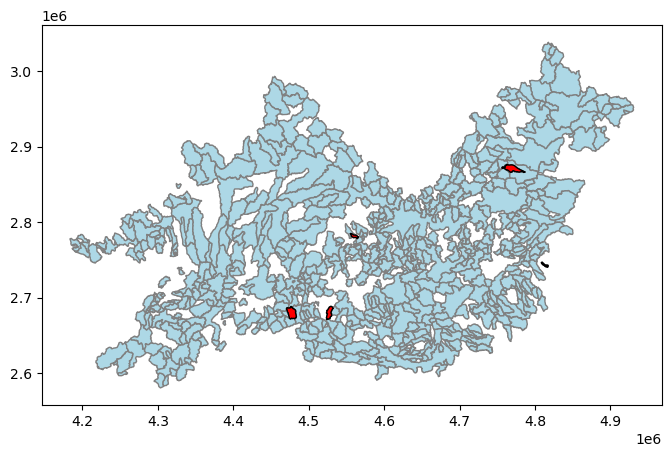

In [82]:
phase = "train"

fig, ax = plt.subplots(figsize=(8, 8))

df = nse_dict[phase]

print(f"{phase} NSE median is {df['NSE'].median()}")

sub_0_basins = df[df["NSE"] < 0]

test_basins = basin_stca_gdf.loc[df["basin"].values]
test_basins.plot(ax=ax, color="lightblue", edgecolor="gray")
highlight = basin_stca_gdf.loc[sub_0_basins["basin"].values]
highlight.plot(ax=ax, color="red", edgecolor="black")

In [83]:
sub_0_basins

,basin,NSE
22,121,-0.314926
53,161,-0.008311
250,392,-0.175714
280,435,-0.008450
633,85,-0.088846


train NSE median 0.583 | mean 0.570
validation NSE median 0.419 | mean -1.001
test NSE median 0.339 | mean -2.185


<Axes: >

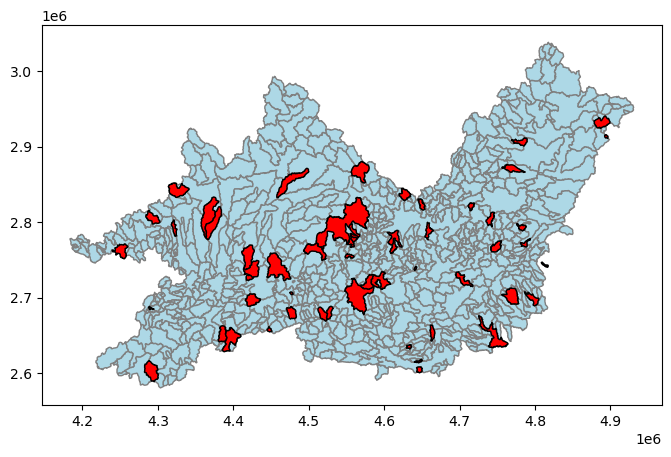

In [84]:
fig, ax = plt.subplots(figsize=(8, 8))

sub_0_basins = []

for phase, df in nse_dict.items():

    print(f"{phase} NSE median {df['NSE'].median():.3f} | mean {df['NSE'].mean():.3f}")

    sub_0_basins.extend(df[df["NSE"]<0]["basin"].values)

basin_stca_gdf.plot(ax=ax, color="lightblue", edgecolor="gray")
highlight = basin_stca_gdf.loc[sub_0_basins]
highlight.plot(ax=ax, color="red", edgecolor="black")

